# Анимация классической сети Петри

Обязательный опыт: три философа, горизонт 30. Кадры соответствуют реальным
событиям. Дополнительный опыт с арбитром показывает продолжающуюся работу.

In [1]:
using DrWatson
@quickactivate "project"
ENV["GKSwstype"] = "100"
using CSV, DataFrames, Plots, Random
include(srcdir("dining_philosophers.jl"))
using .DiningPhilosophers

## Начальные условия и траектории

In [2]:
const N = 3
const TMAX = 30.0
const FPS = 5
const IMAGE_DIR = projectdir("..", "image")
const DATA_DIR = datadir("03_marking_animation")
mkpath(IMAGE_DIR)
mkpath(DATA_DIR)
classical_net, classical_initial = build_classical_network(N)
arbiter_net, arbiter_initial = build_arbiter_network(N)
classical = simulate_stochastic(classical_net, classical_initial, TMAX;
    rng=MersenneTwister(123))
arbiter = simulate_stochastic(arbiter_net, arbiter_initial, TMAX;
    rng=MersenneTwister(123))
CSV.write(joinpath(DATA_DIR, "classical_trajectory.csv"), classical.trajectory)
CSV.write(joinpath(DATA_DIR, "arbiter_trajectory.csv"), arbiter.trajectory)

"/workspace/labs/lab05/project/data/03_marking_animation/arbiter_trajectory.csv"

## Кадр маркировки
Столбец обозначает одну позицию сети, высота — число фишек.

In [3]:
function marking_frame(net, row, variant)
    labels = string.(net.place_names)
    values = [row[name] for name in net.place_names]
    bar(labels, values; legend=false, xlabel="Позиции сети", ylabel="Фишки",
        xrotation=55, ylims=(0, N), color=:steelblue,
        title="$variant, t=$(round(row.time, digits=3))",
        fontfamily="DejaVu Sans", size=(1100, 650),
        bottom_margin=12Plots.mm)
end

marking_frame (generic function with 1 method)

## Анимация возникновения deadlock

[ Info: Saved animation to /workspace/labs/lab05/image/01-animation.gif


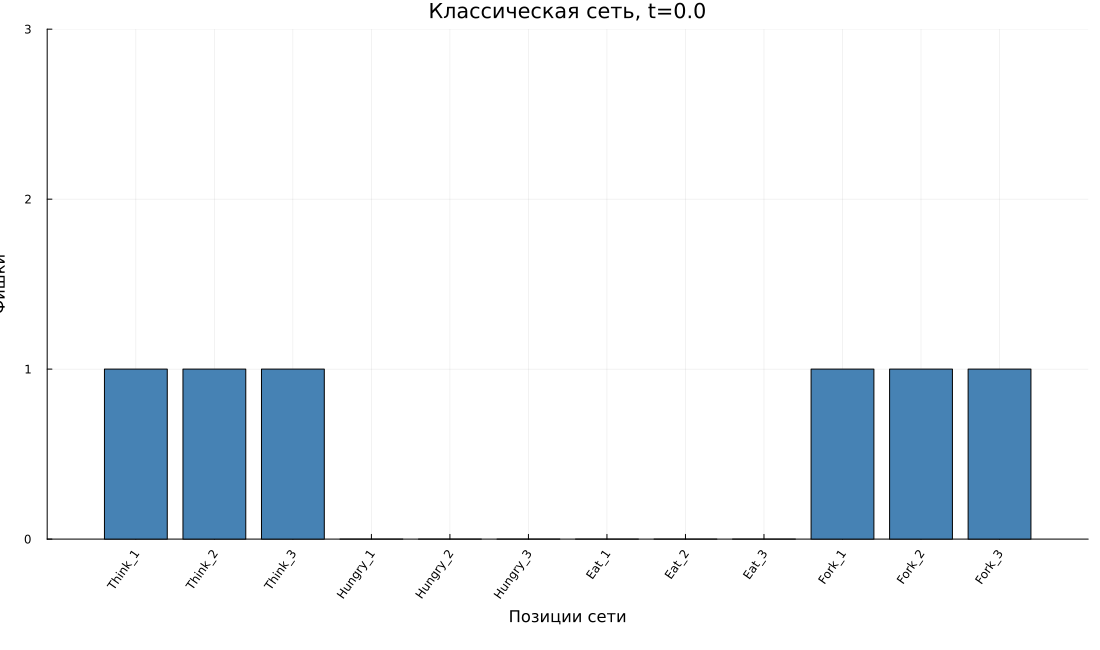

In [4]:
classic_animation = @animate for row in eachrow(classical.trajectory)
    marking_frame(classical_net, row, "Классическая сеть")
end
gif(classic_animation, joinpath(IMAGE_DIR, "01-animation.gif"); fps=FPS)
display(MIME"image/gif"(), read(joinpath(IMAGE_DIR, "01-animation.gif")))

## Начальная и последняя маркировки

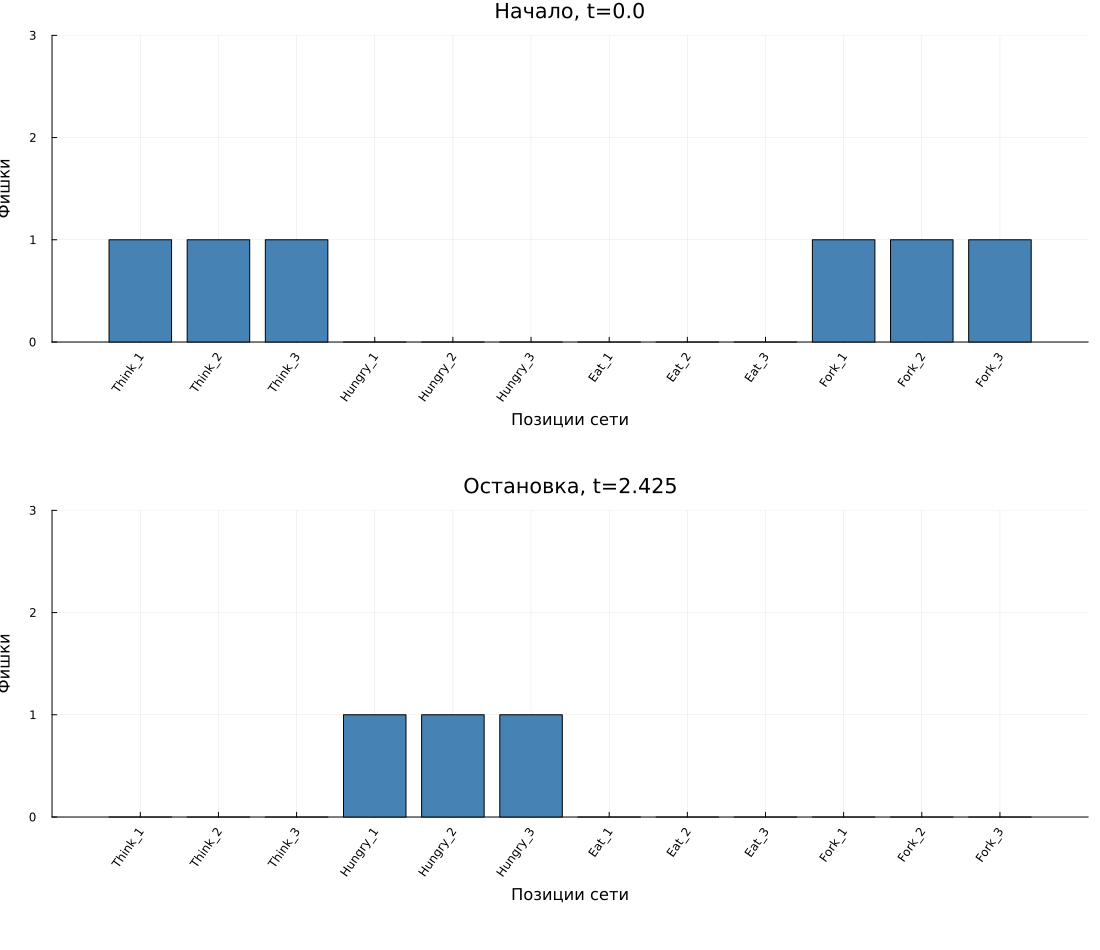

2×6 DataFrame
 Row │ variant       philosophers  horizon  deadlock  events  last_event 
     │ String        Int64         Float64  Bool      Int64   Float64    
─────┼───────────────────────────────────────────────────────────────────
   1 │ Классическая             3     30.0      true       6     2.42548
   2 │ С арбитром               3     30.0     false      36    27.8844


In [6]:
first_frame = marking_frame(classical_net, first(classical.trajectory), "Начало")
last_frame = marking_frame(classical_net, last(classical.trajectory), "Остановка")
static_comparison = plot(first_frame, last_frame; layout=(2, 1), size=(1100, 950))
savefig(static_comparison, joinpath(IMAGE_DIR, "08-plot.png"))
display(static_comparison)
outcomes = DataFrame(variant=["Классическая", "С арбитром"],
    philosophers=fill(N, 2), horizon=fill(TMAX, 2),
    deadlock=[classical.deadlock, arbiter.deadlock],
    events=[classical.events, arbiter.events],
    last_event=[classical.stop_time, arbiter.stop_time])
CSV.write(joinpath(DATA_DIR, "summary.csv"), outcomes)
show(outcomes; allrows=true, allcols=true)
println()

## Дополнительная анимация с арбитром

[ Info: Saved animation to /workspace/labs/lab05/image/02-animation.gif


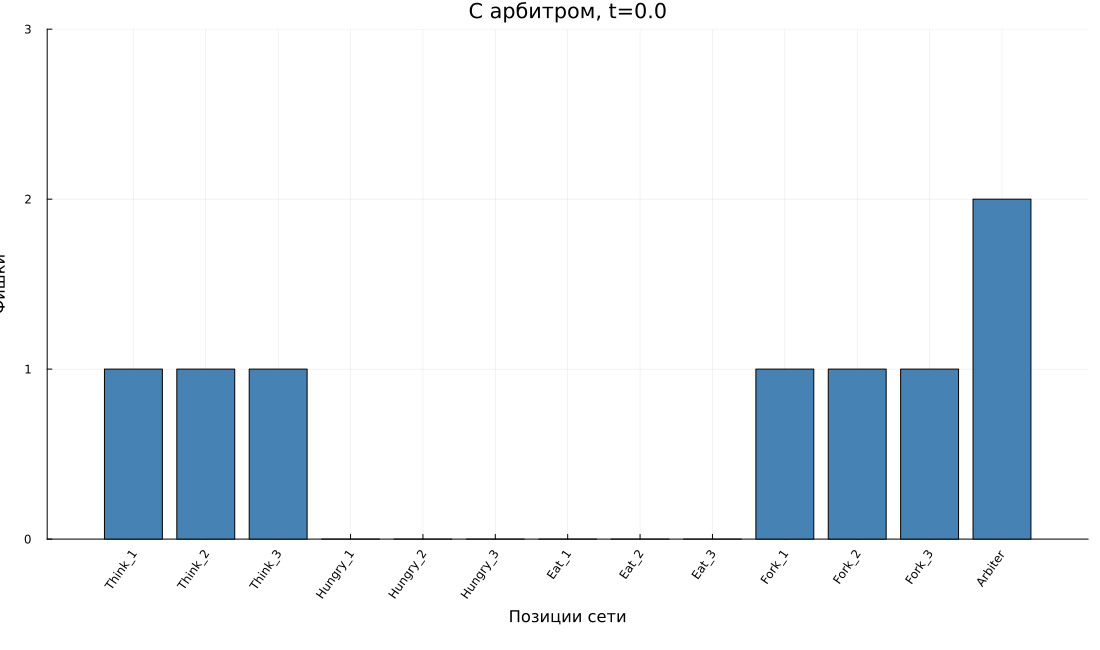

In [5]:
arbiter_animation = @animate for row in eachrow(arbiter.trajectory)
    marking_frame(arbiter_net, row, "С арбитром")
end
gif(arbiter_animation, joinpath(IMAGE_DIR, "02-animation.gif"); fps=FPS)
display(MIME"image/gif"(), read(joinpath(IMAGE_DIR, "02-animation.gif")))

В классической сети последняя маркировка не допускает ни одного перехода.
В модифицированной сети окончание данных обусловлено горизонтом наблюдения,
а не взаимной блокировкой.